In [104]:
import pandas as pd

In [105]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [107]:
df['Sex']=df['Sex'].astype('category')

In [108]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


*  There is null value is present in Age , cabin and embarked column
* Henadle tje missing value by using mean/median

In [110]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Cabin']=df['Cabin'].fillna(df['Cabin'].mode()[0])
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [111]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [112]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Finding the outliers there is two methods
- First is visiualize boxplot
- Second is IQR method

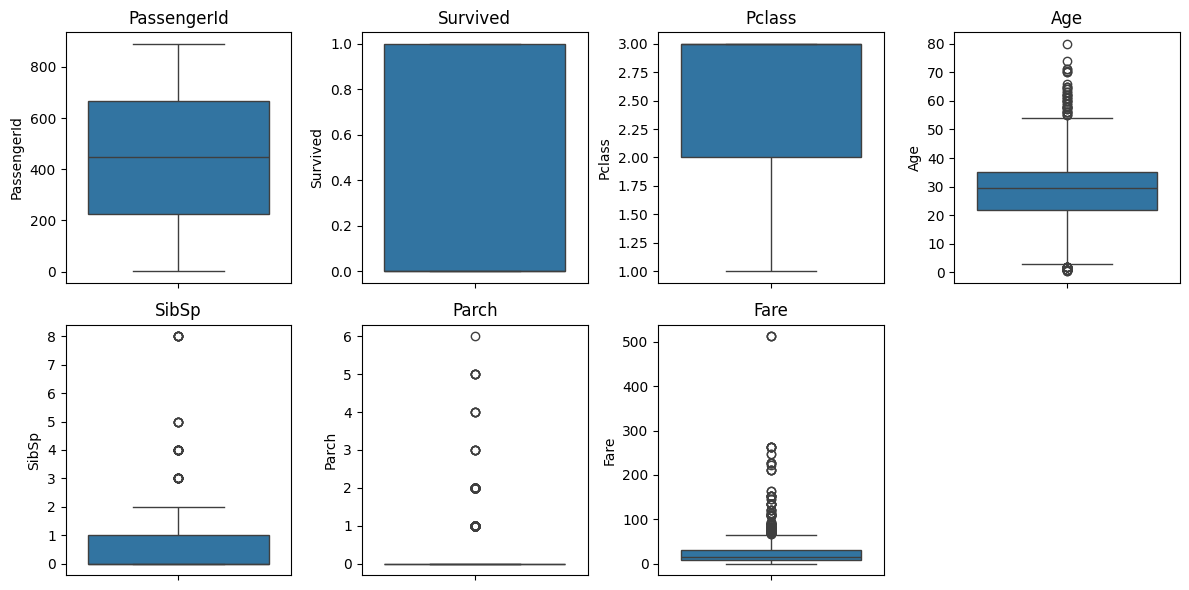

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)  # 2 rows, 4 columns
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [114]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

PassengerId: 0 outliers
Survived: 0 outliers
Pclass: 0 outliers
Age: 66 outliers
SibSp: 46 outliers
Parch: 213 outliers
Fare: 116 outliers


# To check whether a column is normally distributed or skewed

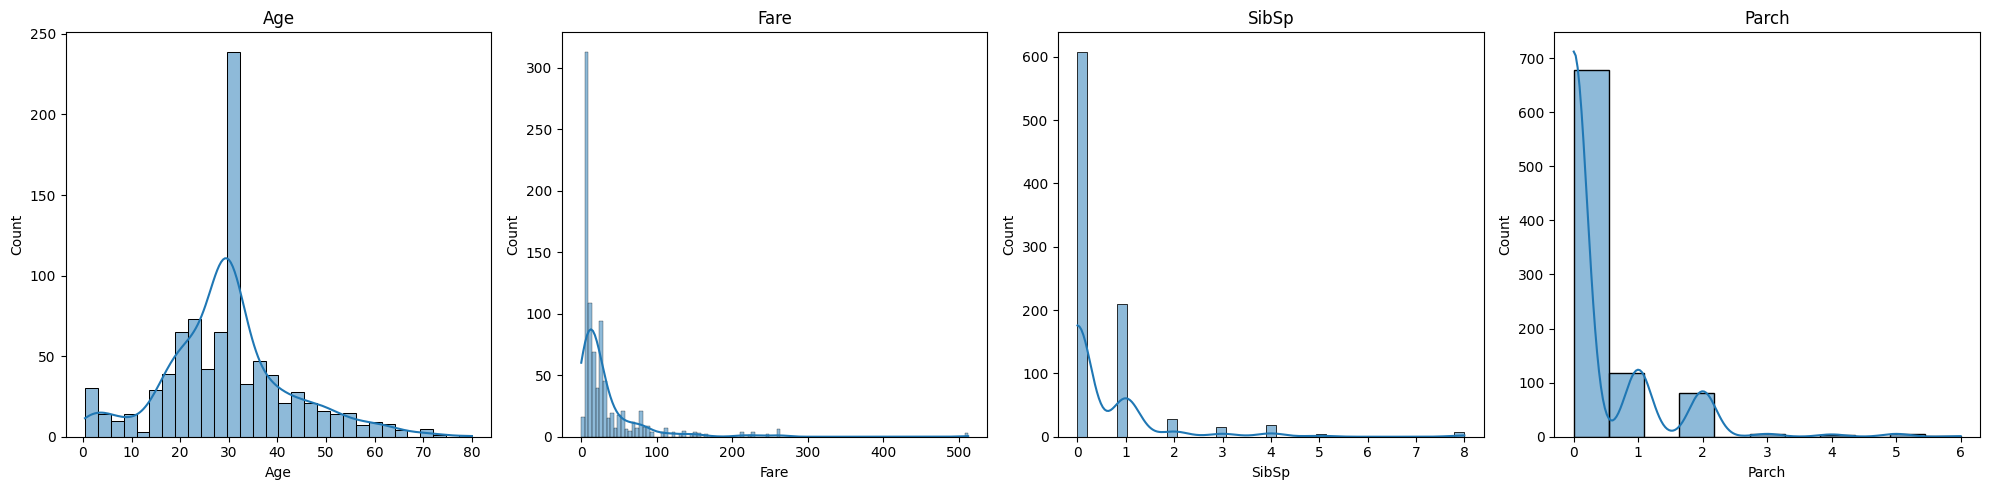

In [115]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
plt.figure(figsize=(20, 5))
for i, col in enumerate(num_cols, 1):

    plt.subplot(1, 4, i)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Remove the outliers

In [116]:
cols = ['Age','Fare', 'SibSp', 'Parch']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(577, 12)


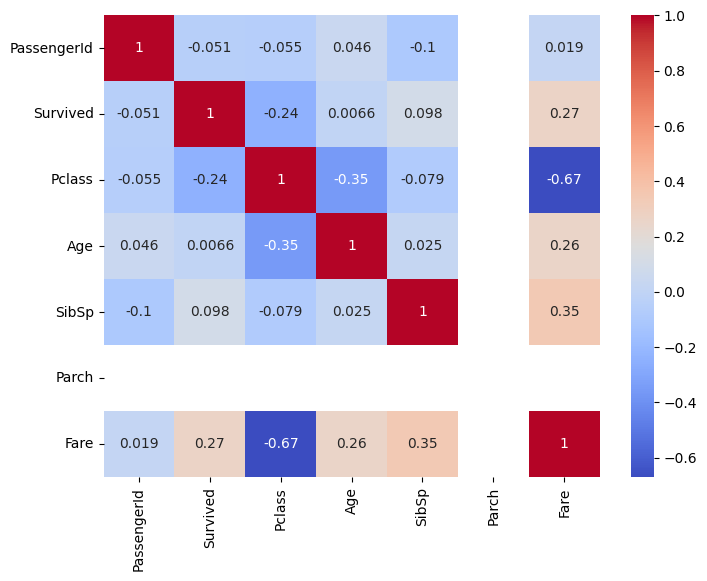

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

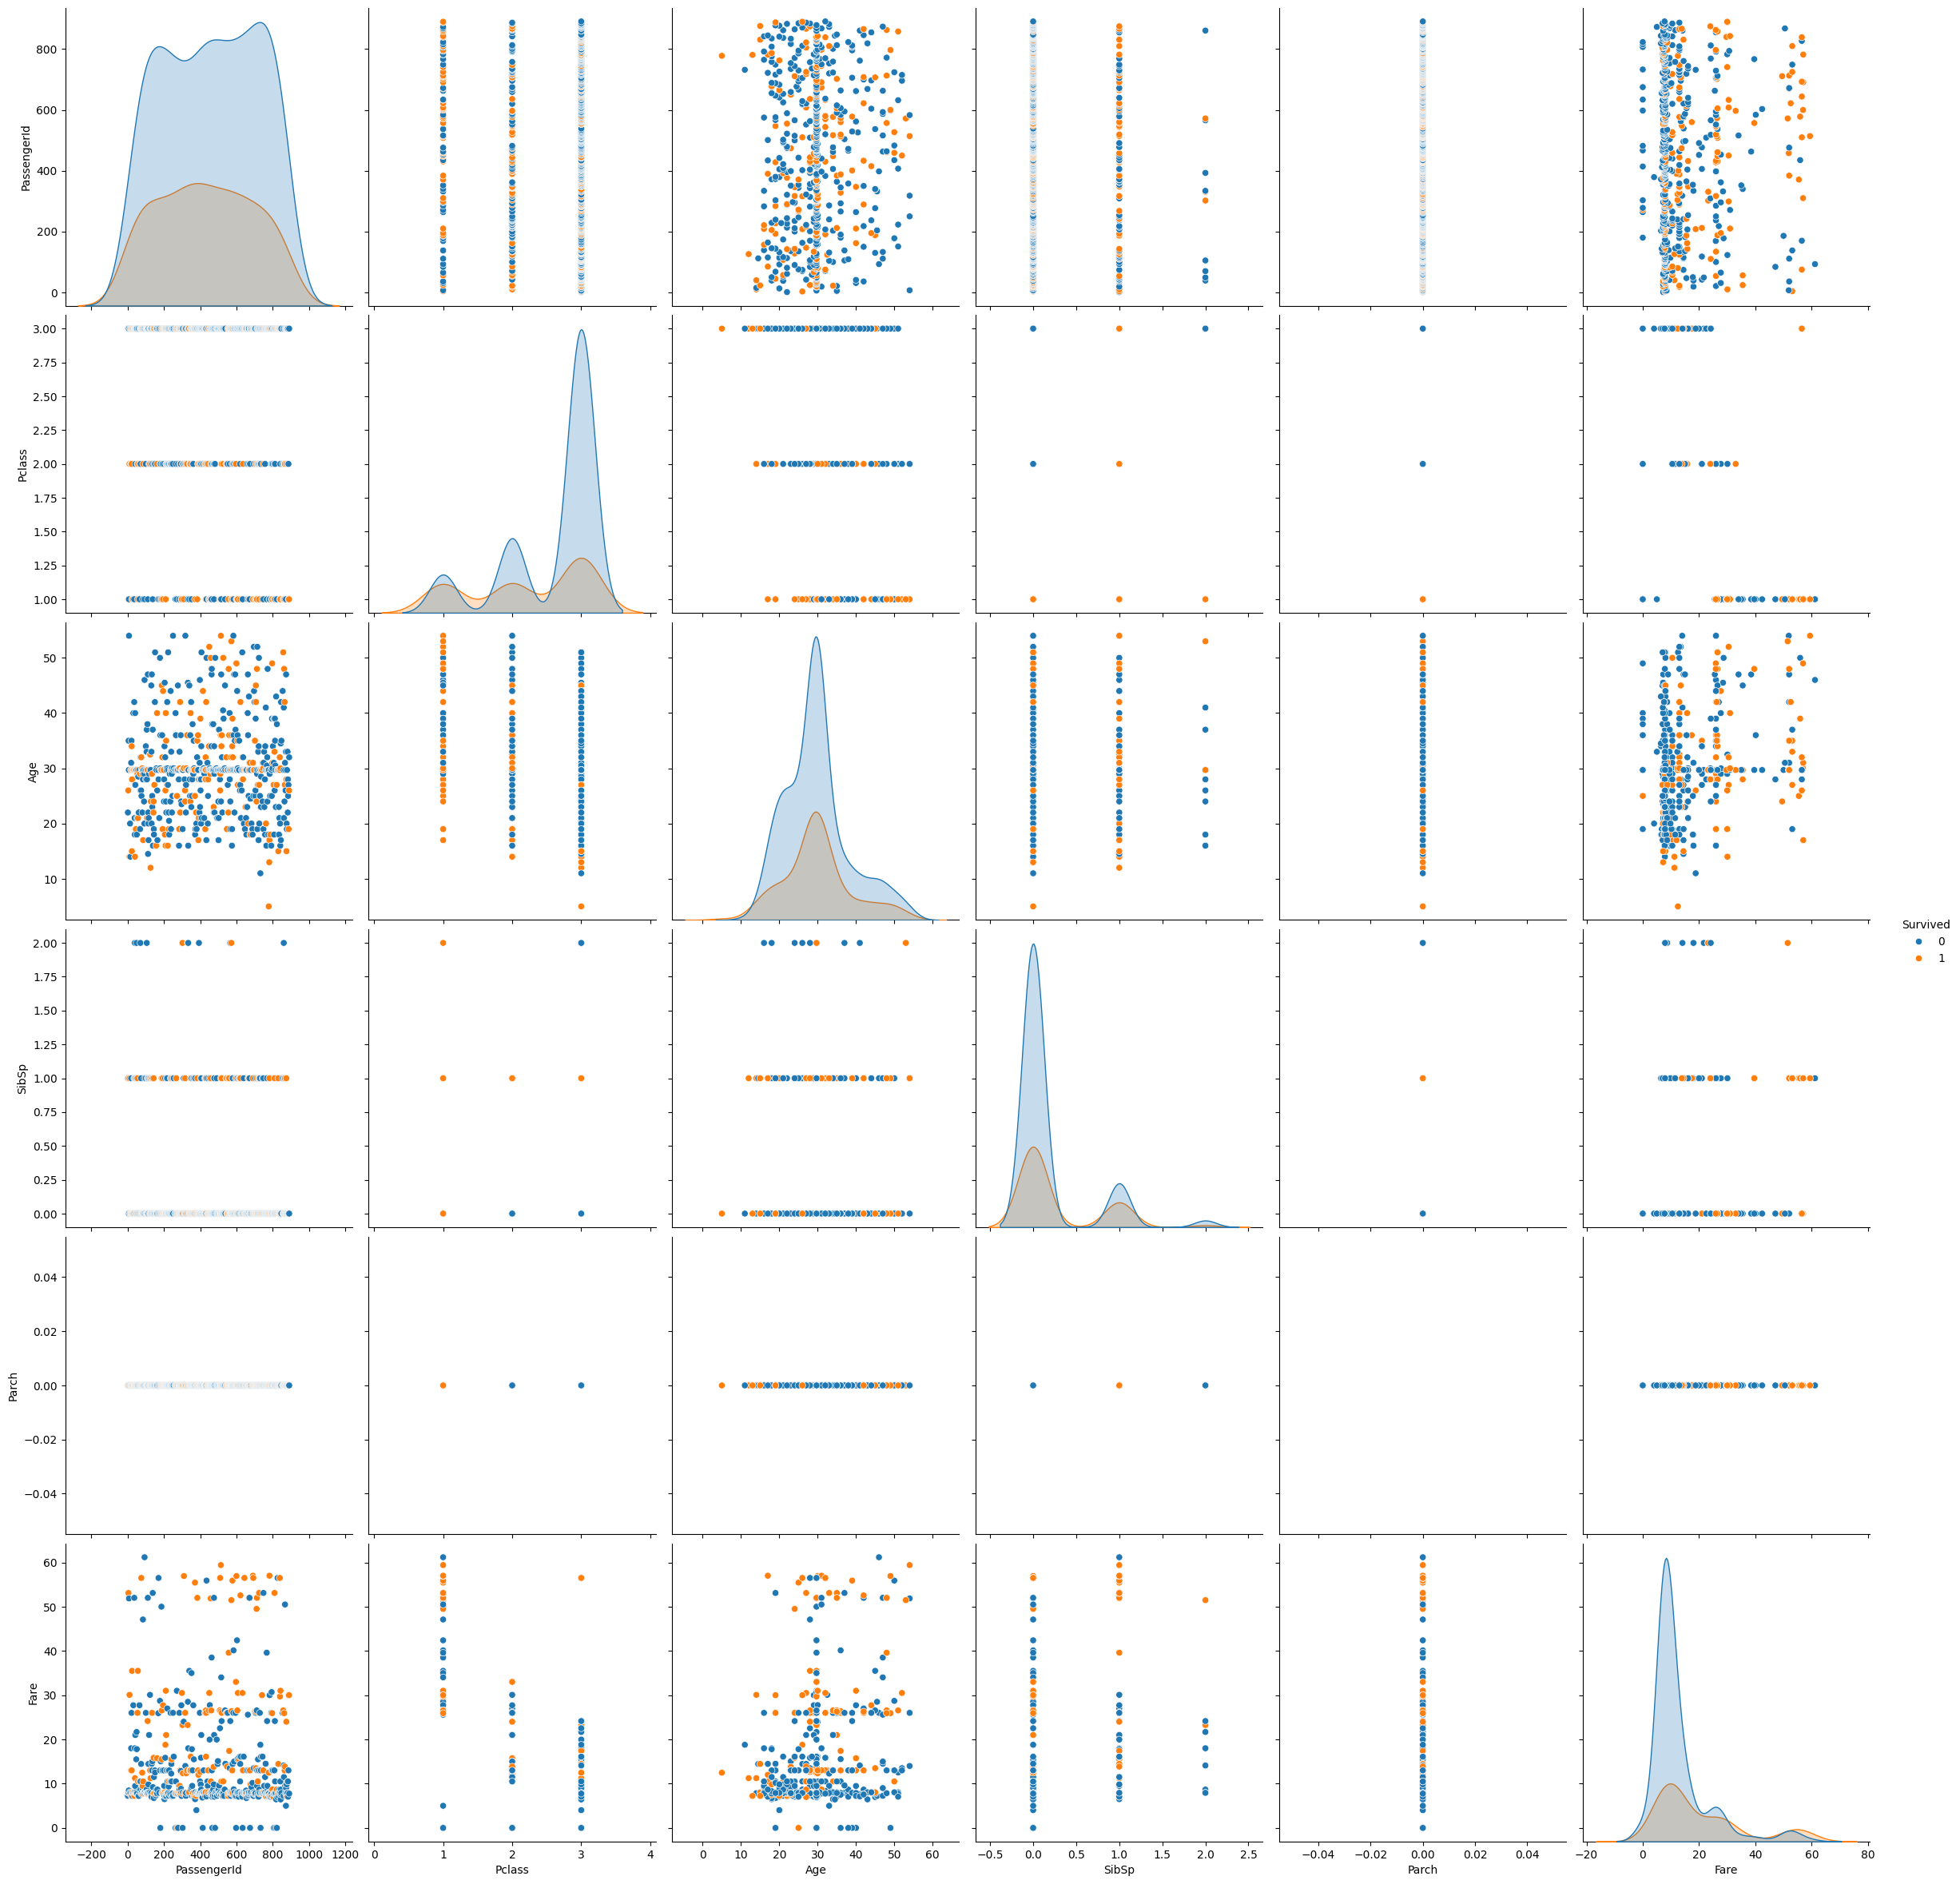

In [118]:
sns.pairplot(df.select_dtypes(include='number'),hue='Survived',
    height=4)
plt.show()



Overall Survival Rate: 0.29982668977469673

Survival by Sex:
 Sex
female    0.72028
male      0.16129
Name: Survived, dtype: float64

Survival by Class:
 Pclass
1    0.530120
2    0.371901
3    0.225201
Name: Survived, dtype: float64


/tmp/ipykernel_925/69349738.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_sex = df.groupby("Sex")["Survived"].mean()


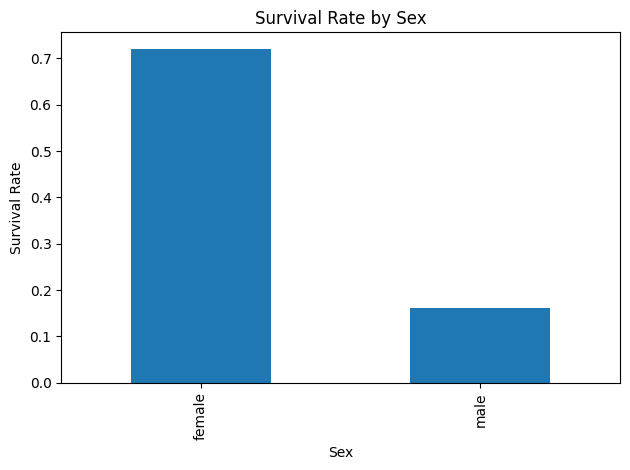

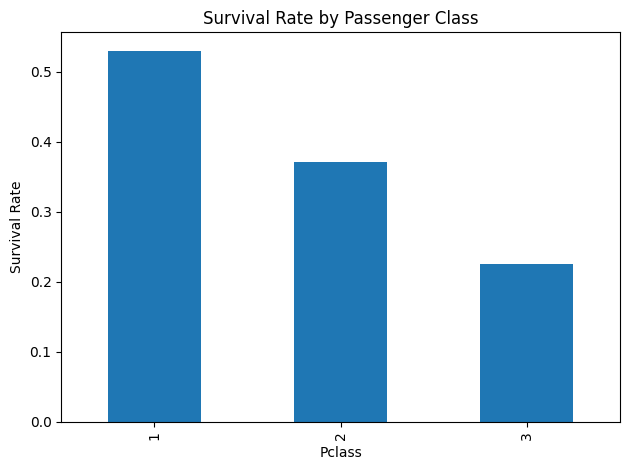

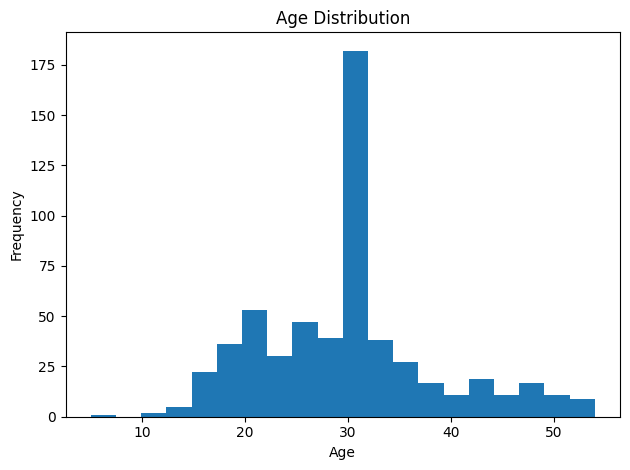

In [119]:
overall_survival_rate = df["Survived"].mean()
print("\nOverall Survival Rate:", overall_survival_rate)
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print("\nSurvival by Sex:\n", survival_by_sex)
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival by Class:\n", survival_by_class)


plt.figure()
survival_by_sex.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


plt.figure()
survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


plt.figure()
df["Age"].dropna().plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Patterns
Most passengers belonged to Pclass 3, indicating that third-class passengers were the majority.
The Age distribution is concentrated between 20 and 40 years.
Most passengers traveled with 0 or 1 family member (SibSp, Parch).
The majority of ticket fares were relatively low.
Female passengers generally had a higher survival rate than male passengers.
# Trends
Survival rate tends to increase as passenger class improves (Class 1 > Class 2 > Class 3).
Higher fare-paying passengers show a greater probability of survival.
Younger passengers appear to have slightly better survival chances than older passengers.
Passengers traveling with small families had better survival rates than those traveling alone or in very large groups.
Fare and Pclass show an inverse relationship; higher-class passengers generally paid higher fares.
# Anomalies (Outliers)
The Fare column contains several extreme values far above the majority of observations.
Some passengers have unusually high values in SibSp and Parch.
Missing values are present in Age, Cabin, and Embarked.
A few passengers paid exceptionally high ticket fares compared to the average.
Cabin information is missing for a large proportion of passengers.

# Based on Visualizations
## From Histogram
Right-skewed distribution in Fare.
Approximately normal distribution in Age.
Most values of SibSp and Parch are concentrated near zero.
## From Boxplot
Significant outliers are present in Fare.
Moderate outliers are visible in SibSp and Parch.
Age contains a few extreme values but fewer than Fare.
## From Correlation Heatmap
Fare and Pclass show a moderate negative correlation.
Survived and Fare show a positive correlation.
Most numerical features have weak correlations with each other.